<a href="https://colab.research.google.com/github/talhaDS04/Detecting-CVD_disease_using_DL.ipynb/blob/main/Heart_Disease_Prediction_using_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Heart Disease Prediction using DL

##Phase 1 : Environment + Dataset Download

###STEP 1: Install Required Libraries

In [ ]:
!pip install wfdb numpy pandas matplotlib scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 41.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


###STEP 2: Download ECG Dataset

In [ ]:
import wfdb

wfdb.dl_database('mitdb', './mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

###STEP 3: Checking Dataset Files

In [ ]:
import os

files = os.listdir('mitdb')
print(files[:10])

['106.atr', '102.dat', '200.atr', '233.dat', '212.hea', '115.hea', '220.hea', '114.dat', '209.atr', '107.atr']


###STEP 4: Understand One Record

In [ ]:
record = wfdb.rdrecord('mitdb/100')
annotation = wfdb.rdann('mitdb/100', 'atr')

print(record)
print(annotation)

###STEP 5: Inspect Signal Shape

In [ ]:
signal = record.p_signal

print(signal.shape)

(650000, 2)


## Phase 2: ECG Visualization + Understanding

###STEP 1: Load ECG Record

In [ ]:
import wfdb

record = wfdb.rdrecord('mitdb/100')
annotation = wfdb.rdann('mitdb/100', 'atr')

signal = record.p_signal

###STEP 2: Plot ECG Signal

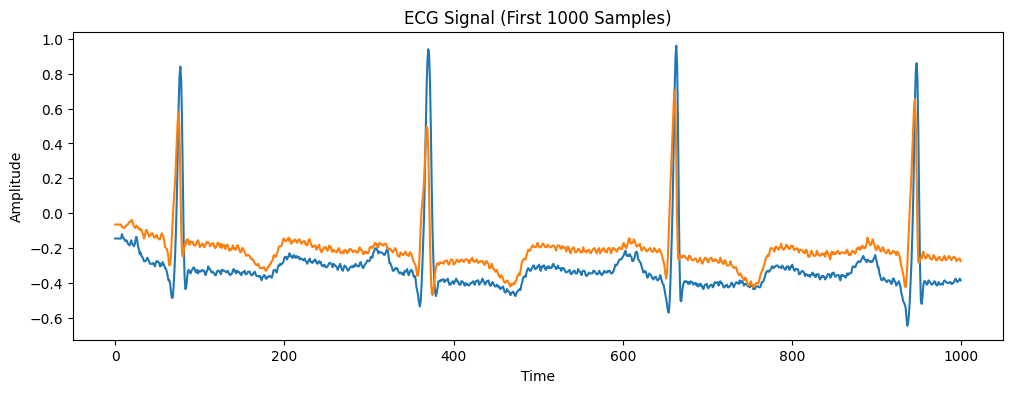

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(signal[:1000])
plt.title("ECG Signal (First 1000 Samples)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

###STEP 3: Inspect Annotations

In [ ]:
print(annotation.symbol[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


###STEP 4: Plot Signal with Annotations

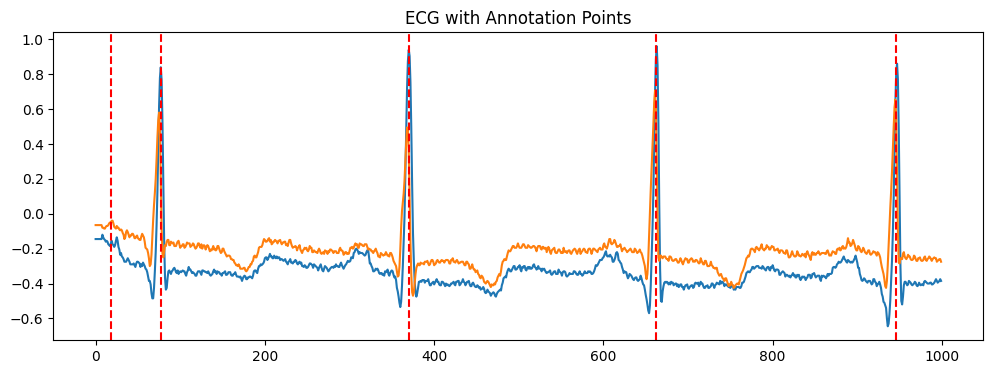

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(signal[:1000])

# mark annotation points
ann_samples = annotation.sample
for i in ann_samples[:20]:
    if i < 1000:
        plt.axvline(x=i, color='r', linestyle='--')

plt.title("ECG with Annotation Points")
plt.show()

##Phase 3: ECG Segmentation + Labeling

###STEP 1: Extract R-peak Positions

In [ ]:
r_peaks = annotation.sample
labels = annotation.symbol

###STEP 2: Create Segments Around Each Beat

In [ ]:
import numpy as np

window_size = 300  # 150 left + 150 right

X = []
y = []

for i in range(len(r_peaks)):
    peak = r_peaks[i]

    start = peak - window_size//2
    end = peak + window_size//2

    # skip edges
    if start < 0 or end > len(signal):
        continue

    segment = signal[start:end, 0]  # use 1 channel

    X.append(segment)
    y.append(labels[i])

X = np.array(X)
y = np.array(y)

###STEP 3: Convert Labels to Binary

In [ ]:
def label_map(label):
    if label == 'N':
        return 0   # Normal
    else:
        return 1   # Abnormal

y = np.array([label_map(l) for l in y])

In [ ]:
print(X.shape)
print(y.shape)

(2271, 300)
(2271,)


In [ ]:
import numpy as np

print(np.unique(y, return_counts=True))

(array([0, 1]), array([2237,   34]))


###STEP 4: Normalize Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X.reshape(-1,1)).reshape(X.shape)

###STEP 5: Reshaping for CNN-LSTM

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

##Phase 4: CNN Model (ECG Feature Extraction)

###STEP 1: Import Libraries

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout

###STEP 2: Build CNN Model

In [ ]:
model = Sequential()

# 🔹 Convolution Layer 1
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(300,1)))
model.add(MaxPooling1D(pool_size=2))

# 🔹 Convolution Layer 2
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))

# 🔹 Flatten
model.add(Flatten())

# 🔹 Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# 🔹 Output
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###STEP 3: Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###STEP 4: Train Model

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9802 - loss: 0.1059 - val_accuracy: 0.9846 - val_loss: 0.0794
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9851 - loss: 0.0806 - val_accuracy: 0.9846 - val_loss: 0.0843
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9851 - loss: 0.0830 - val_accuracy: 0.9846 - val_loss: 0.0796
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9851 - loss: 0.0812 - val_accuracy: 0.9846 - val_loss: 0.0799
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9851 - loss: 0.0860 - val_accuracy: 0.9846 - val_loss: 0.0798
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9851 - loss: 0.0876 - val_accuracy: 0.9846 - val_loss: 0.0821
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9851 - loss: 0.0829 - val_accuracy: 0.9846 - val_loss: 0.0800
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9851 - loss: 0.0831 - val_accuracy: 0.9846 - v

###STEP 5: Evaluate Model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9846 - loss: 0.0809
Test Accuracy: 0.9846153855323792


###STEP 6: Plot Training Results

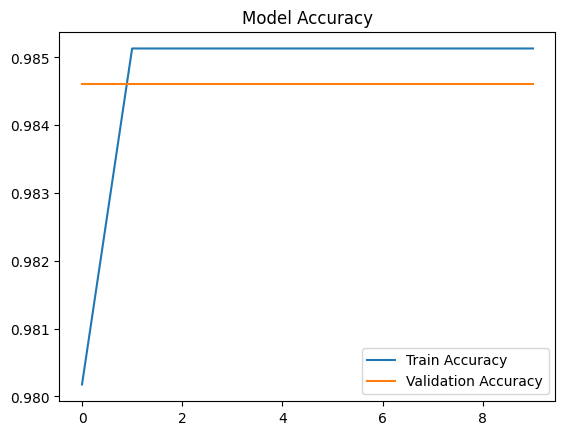

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Model Accuracy")
plt.show()

##Phase 5: CNN + LSTM (Hybrid Model)

###STEP 1: Import LSTM

In [ ]:
from tensorflow.keras.layers import LSTM

###STEP 2: Build CNN + LSTM Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# 🔹 CNN Layers
model.add(Conv1D(32, 3, activation='relu', input_shape=(300,1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(64, 3, activation='relu'))
model.add(MaxPooling1D(2))

# 🔹 LSTM Layer (KEY ADDITION)
model.add(LSTM(64))

# 🔹 Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# 🔹 Output
model.add(Dense(1, activation='sigmoid'))

###STEP 3: Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###STEP 4: Train Model

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9637 - loss: 0.1891 - val_accuracy: 0.9846 - val_loss: 0.0820
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9851 - loss: 0.0851 - val_accuracy: 0.9846 - val_loss: 0.0822
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9851 - loss: 0.0859 - val_accuracy: 0.9846 - val_loss: 0.0824
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9851 - loss: 0.0811 - val_accuracy: 0.9846 - val_loss: 0.0797
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9851 - loss: 0.0839 - val_accuracy: 0.9846 - val_loss: 0.0796
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9851 - loss: 0.0840 - val_accuracy: 0.9846 - val_loss: 0.0799
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9851 - loss: 0.0819 - val_accuracy: 0.9846 - val_loss: 0.0821
Epoch 8/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9851 - loss: 0.0822 - val_accuracy: 0.9846 - v

###STEP 5: Evaluate

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9846 - loss: 0.0795
Test Accuracy: 0.9846153855323792


###STEP 6: Plot Results

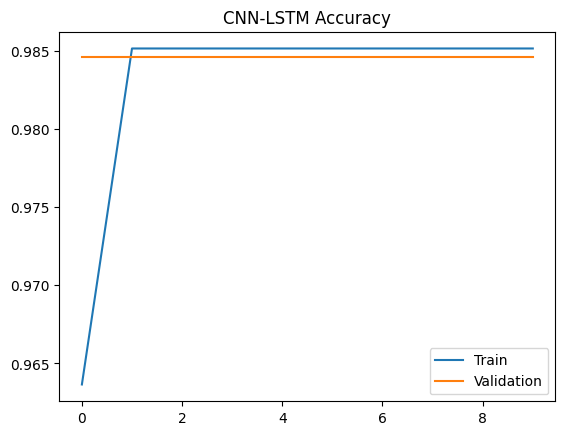

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("CNN-LSTM Accuracy")
plt.show()

##Phase 6: Model Improvement + Proper Evaluation

###STEP 1: Add EarlyStopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

###STEP 2: Add ReduceLROnPlateau

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3
)

###STEP 3: Train Model with Callbacks

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9851 - loss: 0.0864 - val_accuracy: 0.9846 - val_loss: 0.0800 - learning_rate: 0.0010
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9851 - loss: 0.0786 - val_accuracy: 0.9846 - val_loss: 0.0799 - learning_rate: 0.0010
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9851 - loss: 0.0835 - val_accuracy: 0.9846 - val_loss: 0.0799 - learning_rate: 0.0010
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9851 - loss: 0.0814 - val_accuracy: 0.9846 - val_loss: 0.0807 - learning_rate: 0.0010
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9851 - loss: 0.0794 - val_accuracy: 0.9846 - val_loss: 0.0797 - learning_rate: 5.0000e-04
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9851 - loss: 0.0790 - val_accuracy: 0.9846 - val_loss: 0.0798 - learning_rate: 5.0000e-04
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9851 - loss: 0.0827 -

###STEP 4: Predictions

In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


###STEP 5: FULL EVALUATION

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       448
           1       0.00      0.00      0.00         7

    accuracy                           0.98       455
   macro avg       0.49      0.50      0.50       455
weighted avg       0.97      0.98      0.98       455



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###STEP 6: Confusion Matrix

<Axes: >

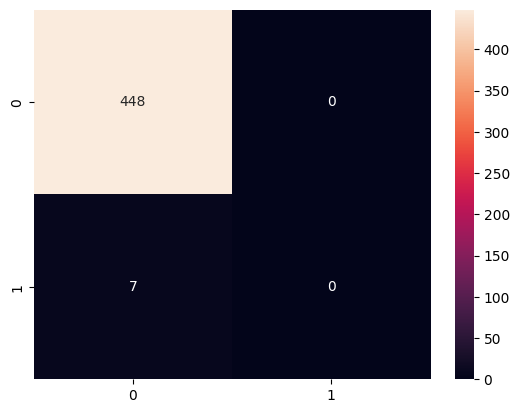

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

###STEP 7: ROC-AUC Score

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

AUC: 0.5


###STEP 8: Plot ROC Curve

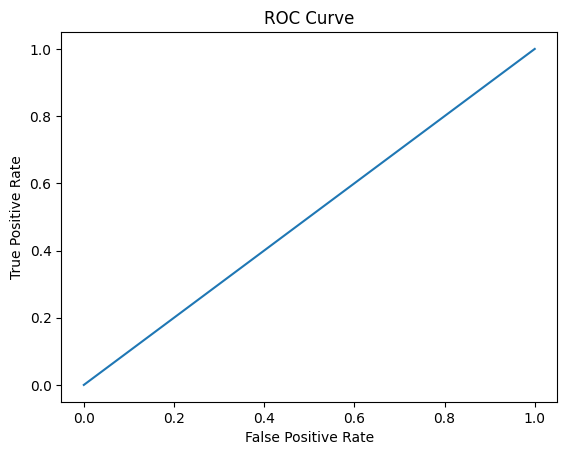

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

##Phase 7: Multi-Modal Fusion (ECG + Clinical Data)

###STEP 1: PREPARE AND CLEAN TABULAR DATA

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/cleveland_heart_disease_full.csv')

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Convert all to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Fill missing values with mean
df = df.fillna(df.mean())

###STEP 2: VERIFICATION OF NULL VALUES

In [ ]:
print("NaN:", df.isnull().sum().sum())

NaN: 0


###STEP 3: PREPARE FEATURES

In [ ]:
# Convert target to binary
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

X_tab = df.drop('target', axis=1)
y_tab = df['target']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_tab_scaled = scaler.fit_transform(X_tab)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tab_scaled,
    y_tab,
    test_size=0.2,
    random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tabular_model = Sequential([

    Dense(64, activation='relu', input_shape=(13,)),

    Dense(32, activation='relu'),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

tabular_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

tabular_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = tabular_model.fit(
    X_train_tab,
    y_train_tab,
    epochs=50,
    batch_size=16,
    validation_data=(X_test_tab, y_test_tab)
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9917 - loss: 0.0527 - val_accuracy: 0.8197 - val_loss: 0.7226
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9917 - loss: 0.0451 - val_accuracy: 0.8197 - val_loss: 0.6888
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9917 - loss: 0.0416 - val_accuracy: 0.8197 - val_loss: 0.7074
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9917 - loss: 0.0381 - val_accuracy: 0.8197 - val_loss: 0.7323
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9917 - loss: 0.0375 - val_accuracy: 0.8197 - val_loss: 0.7435
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9917 - loss: 0.0347 - val_accuracy: 0.8197 - val_loss: 0.7612
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9917 - loss: 0.0332 - val_accuracy: 0.8197 - val_loss: 0.7761
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9917 - loss: 0.0322 - val_accuracy: 0.8197 - val_

In [ ]:
loss, accuracy = tabular_model.evaluate(
    X_test_tab,
    y_test_tab
)

print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8033 - loss: 1.2541
Test Accuracy: 0.8032786846160889


In [ ]:
tabular_model.save("heart_model.h5")

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

###STEP 4: SCALE TABULAR DATA

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)

In [ ]:
from imblearn.over_sampling import SMOTE

X_train_flat = X_train.reshape(X_train.shape[0], -1)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_flat, y_train)

X_res = X_res.reshape(X_res.shape[0], 300, 1)

In [ ]:
print("NaN:", np.isnan(X_tab).sum())
print("Inf:", np.isinf(X_tab).sum())

NaN: 0
Inf: 0


### STEP 5: MATCH ECG + TABULAR DATA

In [ ]:
min_samples = min(len(X_res), len(X_tab))

X_ecg_final = X_res[:min_samples]
X_tab_final = X_tab[:min_samples]
y_final = y_res[:min_samples]

###STEP 6: BUILD FUSION MODEL

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D
from tensorflow.keras.layers import MaxPooling1D, Dropout, Concatenate

# ECG input
ecg_input = Input(shape=(300,1))

x1 = Conv1D(32, 3, activation='relu')(ecg_input)
x1 = MaxPooling1D(2)(x1)

x1 = Conv1D(64, 3, activation='relu')(x1)
x1 = MaxPooling1D(2)(x1)

x1 = LSTM(64)(x1)

# Tabular input
tab_input = Input(shape=(13,))

x2 = Dense(64, activation='relu')(tab_input)
x2 = Dropout(0.3)(x2)

# Fusion
combined = Concatenate()([x1, x2])

x = Dense(64, activation='relu')(combined)
x = Dropout(0.3)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=[ecg_input, tab_input], outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###STEP 8: TRAINING AND EVALUATION

In [ ]:
history = model.fit(
    [X_ecg_final, X_tab_final],
    y_final,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.7893 - loss: 0.5577 - val_accuracy: 1.0000 - val_loss: 0.3160
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9959 - loss: 0.1562 - val_accuracy: 1.0000 - val_loss: 0.0192
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9959 - loss: 0.0384 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9959 - loss: 0.0292 - val_accuracy: 1.0000 - val_loss: 8.7308e-04
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9959 - loss: 0.0337 - val_accuracy: 1.0000 - val_loss: 7.0888e-04
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9959 - loss: 0.0326 - val_accuracy: 1.0000 - val_loss: 8.9653e-04
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9959 - loss: 0.0301 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9959 - loss: 0.0274 - val_accuracy: 1.0000 - val_l

In [ ]:
model.save("heart_model.h5")

##Phase 8: SHAP Implementation (Model Explainability) -> Important

###STEP 1: Install SHAP

In [ ]:
!pip install shap

###STEP 2: Create Explainer

In [ ]:
import shap

# Use a smaller sample (important for speed)
X_sample = X_tab_final[:100]

explainer = shap.Explainer(model, X_sample)

###STEP 3: Build Tabular Model (for SHAP)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

tab_model = Sequential()

tab_model.add(Dense(64, activation='relu', input_shape=(13,)))
tab_model.add(Dropout(0.3))
tab_model.add(Dense(32, activation='relu'))
tab_model.add(Dense(1, activation='sigmoid'))

tab_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


###STEP 4: Train Tabular Model

In [ ]:
tab_model.fit(
    X_tab_final, y_final,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9587 - loss: 0.4211 - val_accuracy: 1.0000 - val_loss: 0.3745
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9917 - loss: 0.2784 - val_accuracy: 1.0000 - val_loss: 0.2505
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9959 - loss: 0.1869 - val_accuracy: 1.0000 - val_loss: 0.1589
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9959 - loss: 0.1156 - val_accuracy: 1.0000 - val_loss: 0.1006
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9959 - loss: 0.0798 - val_accuracy: 1.0000 - val_loss: 0.0647
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9959 - loss: 0.0576 - val_accuracy: 1.0000 - val_loss: 0.0437
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9959 - loss: 0.0480 - val_accuracy: 1.0000 - val_loss: 0.0311
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9959 - loss: 0.0373 - val_accuracy: 1.0000 - val_loss: 0.0232
Ep

###STEP 5: Apply SHAP

In [ ]:
import shap
shap.initjs()

explainer = shap.Explainer(tab_model, X_tab[:100])
shap_values = explainer(X_tab[:100])

PermutationExplainer explainer: 101it [00:12,  2.62it/s]                         


In [ ]:
tab_model.save("final_trained_model.keras")

###STEP 6: Summary Plot (MOST IMPORTANT)

/tmp/ipykernel_4094/3687019860.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_tab_final[:100])


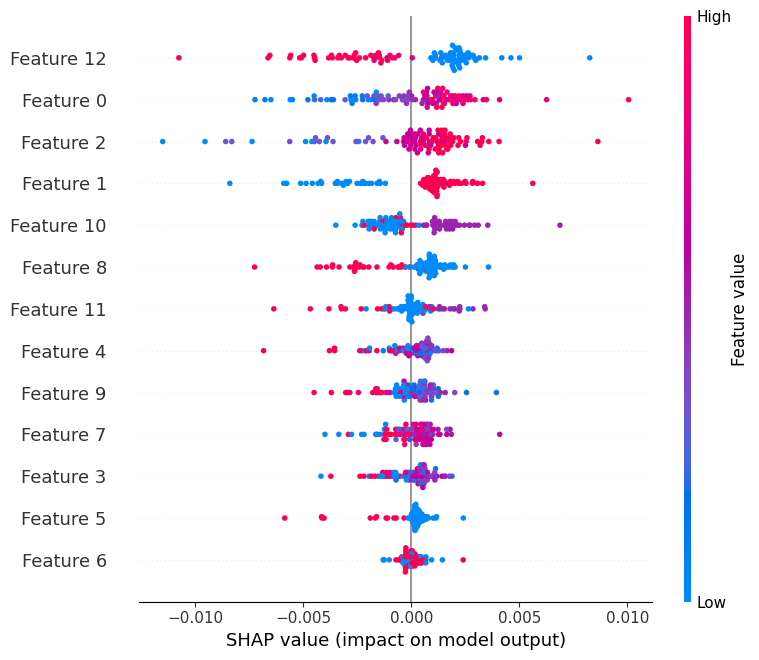

In [ ]:
shap.summary_plot(shap_values, X_tab_final[:100])

###STEP 7: Feature Names (IMPORTANT FOR REPORT)

/tmp/ipykernel_4094/844293890.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_tab_final[:100], feature_names=feature_names)


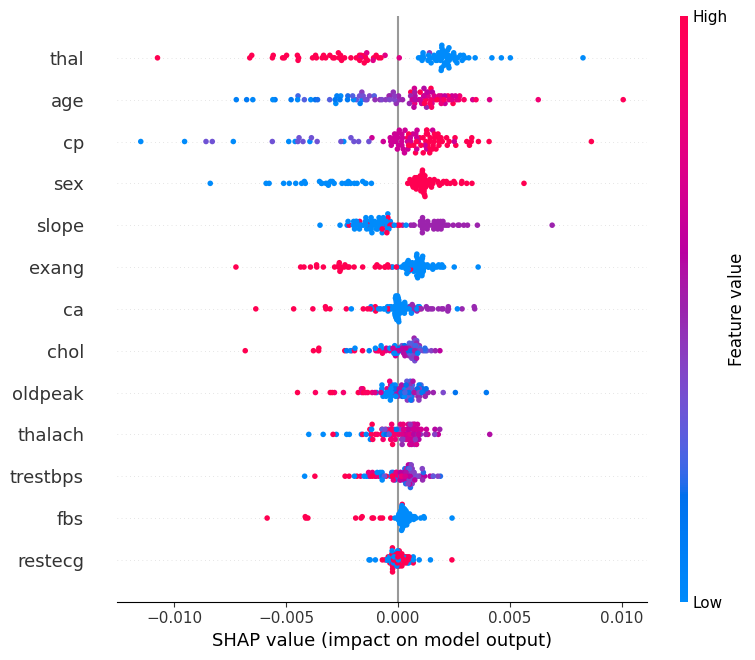

In [ ]:
feature_names = [
    'age','sex','cp','trestbps','chol',
    'fbs','restecg','thalach','exang',
    'oldpeak','slope','ca','thal'
]

shap.summary_plot(shap_values, X_tab_final[:100], feature_names=feature_names)

###STEP 8: Force Plot

In [ ]:
import shap
shap.initjs()
shap.plots.force(shap_values[0])

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']